# Machine Learning for CICY 4-Folds

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
import os
import time
import gzip
import json
from IPython.display import Image
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score
from tensorflow import keras
from nn_tools.nn_models.models import *

import warnings
warnings.filterwarnings('ignore', message='The objective has been evaluated at this point before.')

# set matplot
sns.set()
PREFIX = 'cicy4_'
SUFFIX = '_inception'

# set memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)
        
# set random seed
RAND = 123
np.random.seed(RAND)
tf.random.set_seed(RAND)

In [2]:
proot = lambda s: os.path.join('.', s)
pdata = lambda s: os.path.join(proot('data'), s)
pimg  = lambda s: os.path.join(proot('img'), s)
ppred = lambda s: os.path.join(proot('pred'), s)

os.makedirs(proot('data'), exist_ok=True)
os.makedirs(proot('img'), exist_ok=True)
os.makedirs(proot('pred'), exist_ok=True)

## Download and Read the Dataset

In [3]:
data = keras.utils.get_file('cicy4_eng.json.gz',
                            'https://riccardo.rigoletto.dynu.net/datasets/cicy4/cicy4_eng.json.gz',
                            cache_dir='.',
                            cache_subdir='data'
                           )

## Reading the Dataset

In [4]:
df = pd.read_json(pdata('cicy4_eng.json.gz'), orient='index')

In [5]:
# select only non product manifolds
df = df.loc[df['isprod'] == False]

# select only complete entries
df = df.dropna()

## Building the Configuration Matrices (Sparse to Dense)

In [6]:
# get the max shape of the matrix
shape = df['size'].max()

# get the offset and pad the matrix
offset = lambda s: [(0, shape[i] - np.shape(s)[i]) for i in range(len(shape))]
df['matrix'] = df['matrix'].apply(lambda s: np.pad(s, offset(s), mode='constant'))

## Building the Vector Features (Sparse to Dense)

In [7]:
# get the max length
dim_cp_shape  = df['dim_cp'].apply(np.shape).max()
deg_eqs_shape = df['deg_eqs'].apply(np.shape).max()

# get the offset and pad
offset_dim_cp = lambda s: (0, dim_cp_shape[0] - np.shape(s)[0])
df['dim_cp']  = df['dim_cp'].apply(lambda s: np.pad(s, offset_dim_cp(s), mode='constant'))

offset_deg_eqs = lambda s: (0, deg_eqs_shape[0] - np.shape(s)[0])
df['deg_eqs']   = df['deg_eqs'].apply(lambda s: np.pad(s, offset_deg_eqs(s), mode='constant'))

## Plots

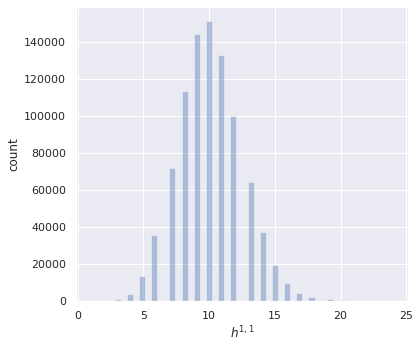

In [8]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.distplot(df['h11'],
             kde=False,
             ax=ax
            )
ax.set_xlabel('$h^{1,1}$')
ax.set_ylabel('count')
ax.set_yscale('log')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h11_distribution' + SUFFIX + '.pdf'), format='pdf', dpi=150)

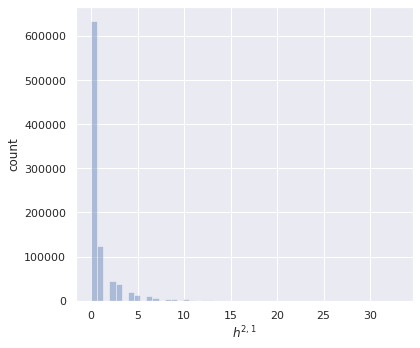

In [9]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.distplot(df['h21'],
             kde=False,
             ax=ax
            )
ax.set_xlabel('$h^{2,1}$')
ax.set_ylabel('count')
ax.set_yscale('log')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h21_distribution' + SUFFIX + '.pdf'), format='pdf', dpi=150)

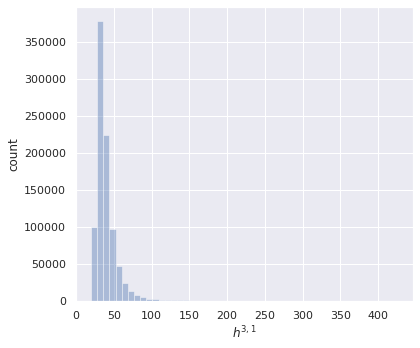

In [10]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.distplot(df['h31'],
             kde=False,
             ax=ax
            )
ax.set_xlabel('$h^{3,1}$')
ax.set_ylabel('count')
ax.set_yscale('log')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h31_distribution' + SUFFIX + '.pdf'), format='pdf', dpi=150)

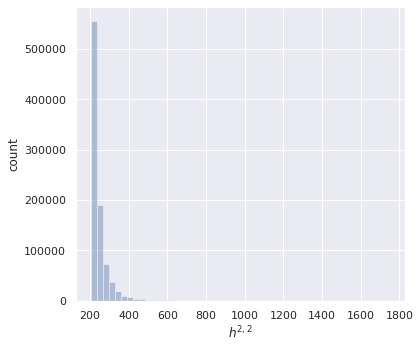

In [11]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.distplot(df['h22'],
             kde=False,
             ax=ax
            )
ax.set_xlabel('$h^{2,2}$')
ax.set_ylabel('count')
ax.set_yscale('log')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h22_distribution' + SUFFIX + '.pdf'), format='pdf', dpi=150)

## Correlations

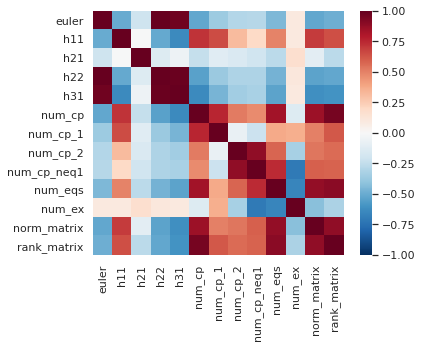

In [12]:
corr = df[['euler',
           'h11',
           'h21',
           'h22',
           'h31',
           'num_cp',
           'num_cp_1',
           'num_cp_2',
           'num_cp_neq1',
           'num_eqs',
           'num_ex',
           'norm_matrix',
           'rank_matrix'
          ]
         ].corr()

_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.heatmap(corr,
            vmin=-1.0,
            vmax=1.0,
            cmap='RdBu_r',
            center=0.0
           )

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'correlations' + SUFFIX + '.pdf'), format='pdf', dpi=150)

## Train, Validation, Test Splits

In [13]:
batch_size = 64

In [14]:
df_train, df_test = train_test_split(df, test_size=0.02, shuffle=True, random_state=RAND)
df_val, df_test   = train_test_split(df_test, test_size=0.5, shuffle=True, random_state=RAND)

print(f'Training set:   {df_train.shape[0]:d} samples (fraction: {df_train.shape[0] / df.shape[0]:.3f})')
print(f'Validation set: {df_val.shape[0]:d} samples (fraction: {df_val.shape[0] / df.shape[0]:.3f})')
print(f'Test set:       {df_test.shape[0]:d} samples (fraction: {df_test.shape[0] / df.shape[0]:.3f})')

Training set:   887570 samples (fraction: 0.980)
Validation set: 9057 samples (fraction: 0.010)
Test set:       9057 samples (fraction: 0.010)


## Remove Outliers from Train Set

In [15]:
low_quantile  = 0.05
high_quantile = 0.95

quantile = df_train.quantile(q=[low_quantile, high_quantile])
quantile

,euler,favour,h11,h21,h22,h31,isprod,num_cp,num_eqs,num_cp_1,...,min_dim_cp,max_dim_cp,mean_dim_cp,std_dim_cp,median_dim_cp,min_deg_eqs,max_deg_eqs,mean_deg_eqs,std_deg_eqs,median_deg_eqs
0.05,288.0,0.0,6.0,0.0,204.0,27.0,0.0,6.0,6.0,2.0,...,1.0,2.0,1.307692,0.458258,1.0,1.0,1.0,1.000000,0.000000,1.0
0.95,480.0,1.0,14.0,5.0,332.0,64.0,0.0,12.0,14.0,7.0,...,1.0,4.0,2.000000,1.069045,2.0,1.0,2.0,1.285714,0.471405,1.0


In [16]:
df_train = df_train.loc[(df_train['h11'] >= quantile['h11'].loc[low_quantile]) & (df_train['h11'] <= quantile['h11'].loc[high_quantile])
                        & (df_train['h21'] >= quantile['h21'].loc[low_quantile]) & (df_train['h21'] <= quantile['h21'].loc[high_quantile])
                        & (df_train['h31'] >= quantile['h31'].loc[low_quantile]) & (df_train['h31'] <= quantile['h31'].loc[high_quantile])
                        & (df_train['h22'] >= quantile['h22'].loc[low_quantile]) & (df_train['h22'] <= quantile['h22'].loc[high_quantile])
                       ]
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 760653 entries, 470930 to 788943
Data columns (total 31 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   euler           760653 non-null  int64  
 1   favour          760653 non-null  bool   
 2   h11             760653 non-null  float64
 3   h21             760653 non-null  float64
 4   h22             760653 non-null  float64
 5   h31             760653 non-null  float64
 6   isprod          760653 non-null  bool   
 7   matrix          760653 non-null  object 
 8   size            760653 non-null  object 
 9   num_cp          760653 non-null  int64  
 10  num_eqs         760653 non-null  int64  
 11  num_cp_1        760653 non-null  int64  
 12  num_cp_2        760653 non-null  int64  
 13  num_cp_neq1     760653 non-null  int64  
 14  num_ex          760653 non-null  int64  
 15  norm_matrix     760653 non-null  float64
 16  rank_matrix     760653 non-null  int64  
 17  dim_c

In [17]:
df_train.to_csv(pdata(PREFIX + 'train_set' + SUFFIX + '.csv'), index=False)
df_val.to_csv(pdata(PREFIX + 'val_set' + SUFFIX + '.csv'), index=False)
df_test.to_csv(pdata(PREFIX + 'test_set' + SUFFIX + '.csv'), index=False)

## Rescale the Matrices

In [18]:
scale = df_train['matrix'].apply(np.max).max()

In [19]:
df_train['matrix'] = df_train['matrix'] / scale
df_val['matrix']   = df_val['matrix'] / scale
df_test['matrix']  = df_test['matrix'] / scale

## Reshape Layers for CNN

In [20]:
reshape = tuple(shape + [1])

In [21]:
df_train['matrix'] = df_train['matrix'].apply(lambda x: np.reshape(x, reshape))
df_val['matrix']   = df_val['matrix'].apply(lambda x: np.reshape(x, reshape))
df_test['matrix']  = df_test['matrix'].apply(lambda x: np.reshape(x, reshape))

## Create Dataset Generators

In [22]:
train_features = {'matrix': list(df_train['matrix'].values),
                  'scalars': list(df_train[['num_cp', 'norm_matrix', 'rank_matrix', 'num_eqs', 'num_ex']].values),
                  'dim_cp': list(df_train['dim_cp'].values),
                  'deg_eqs': list(df_train['deg_eqs'].values)
                 }
val_features = {'matrix': list(df_val['matrix'].values),
                'scalars': list(df_val[['num_cp', 'norm_matrix', 'rank_matrix', 'num_eqs', 'num_ex']].values),
                'dim_cp': list(df_val['dim_cp'].values),
                'deg_eqs': list(df_val['deg_eqs'].values)
               }
test_features = {'matrix': list(df_test['matrix'].values),
                 'scalars': list(df_test[['num_cp', 'norm_matrix', 'rank_matrix', 'num_eqs', 'num_ex']].values),
                 'dim_cp': list(df_test['dim_cp'].values),
                 'deg_eqs': list(df_test['deg_eqs'].values)
                }

In [23]:
scalars_shape = train_features['scalars'][0].shape

In [24]:
train_labels = {'h11': list(df_train['h11'].values.astype(np.int)),
                'h21': list(df_train['h21'].values.astype(np.int)),
                'h31': list(df_train['h31'].values.astype(np.int)),
                'h22': list(df_train['h22'].values.astype(np.int)),
               }
val_labels = {'h11': list(df_val['h11'].values.astype(np.int)),
              'h21': list(df_val['h21'].values.astype(np.int)),
              'h31': list(df_val['h31'].values.astype(np.int)),
              'h22': list(df_val['h22'].values.astype(np.int)),
             }
test_labels = {'h11': list(df_test['h11'].values.astype(np.int)),
               'h21': list(df_test['h21'].values.astype(np.int)),
               'h31': list(df_test['h31'].values.astype(np.int)),
               'h22': list(df_test['h22'].values.astype(np.int)),
              }

In [25]:
train = tf.data.Dataset.from_tensor_slices((train_features, train_labels)).cache().batch(batch_size).prefetch(2)
val = tf.data.Dataset.from_tensor_slices((val_features, val_labels)).cache().batch(batch_size).prefetch(2)
test = tf.data.Dataset.from_tensor_slices((test_features, test_labels)).cache().batch(batch_size).prefetch(2)

## Model Building

### Inception Network

In [26]:
matrix = nn_inception(input_shape=reshape,
                      name='matrix',
                      learning_rate=1.0e-3,
                      conv_layers=[64, 64, 32],
                      conv_alpha=0.0,
                      conv_class=None,
                      conv_single=False,
                      conv_red=0,
                      feat_map=0,
                      recurrent=False,
                      fc_layers=[],
                      fc_alpha=0.0,
                      dropout=0.0,
                      full_dropout=0.1,
                      batchnorm=0.99,
                      last_relu=True,
                      loss_weights=[0.25, 0.25, 0.25, 0.25],
                      l1_reg=1.0e-5,
                      l2_reg=1.0e-5,
                      output_layers=False
                     )

matrix.summary()

Model: "matrix"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
matrix (InputLayer)             [(None, 16, 20, 1)]  0                                            
__________________________________________________________________________________________________
matrix_convAa_0 (Conv2D)        (None, 16, 20, 64)   1088        matrix[0][0]                     
__________________________________________________________________________________________________
matrix_convAb_0 (Conv2D)        (None, 16, 20, 64)   1344        matrix[0][0]                     
__________________________________________________________________________________________________
matrix_actAa_0 (LeakyReLU)      (None, 16, 20, 64)   0           matrix_convAa_0[0][0]            
_____________________________________________________________________________________________

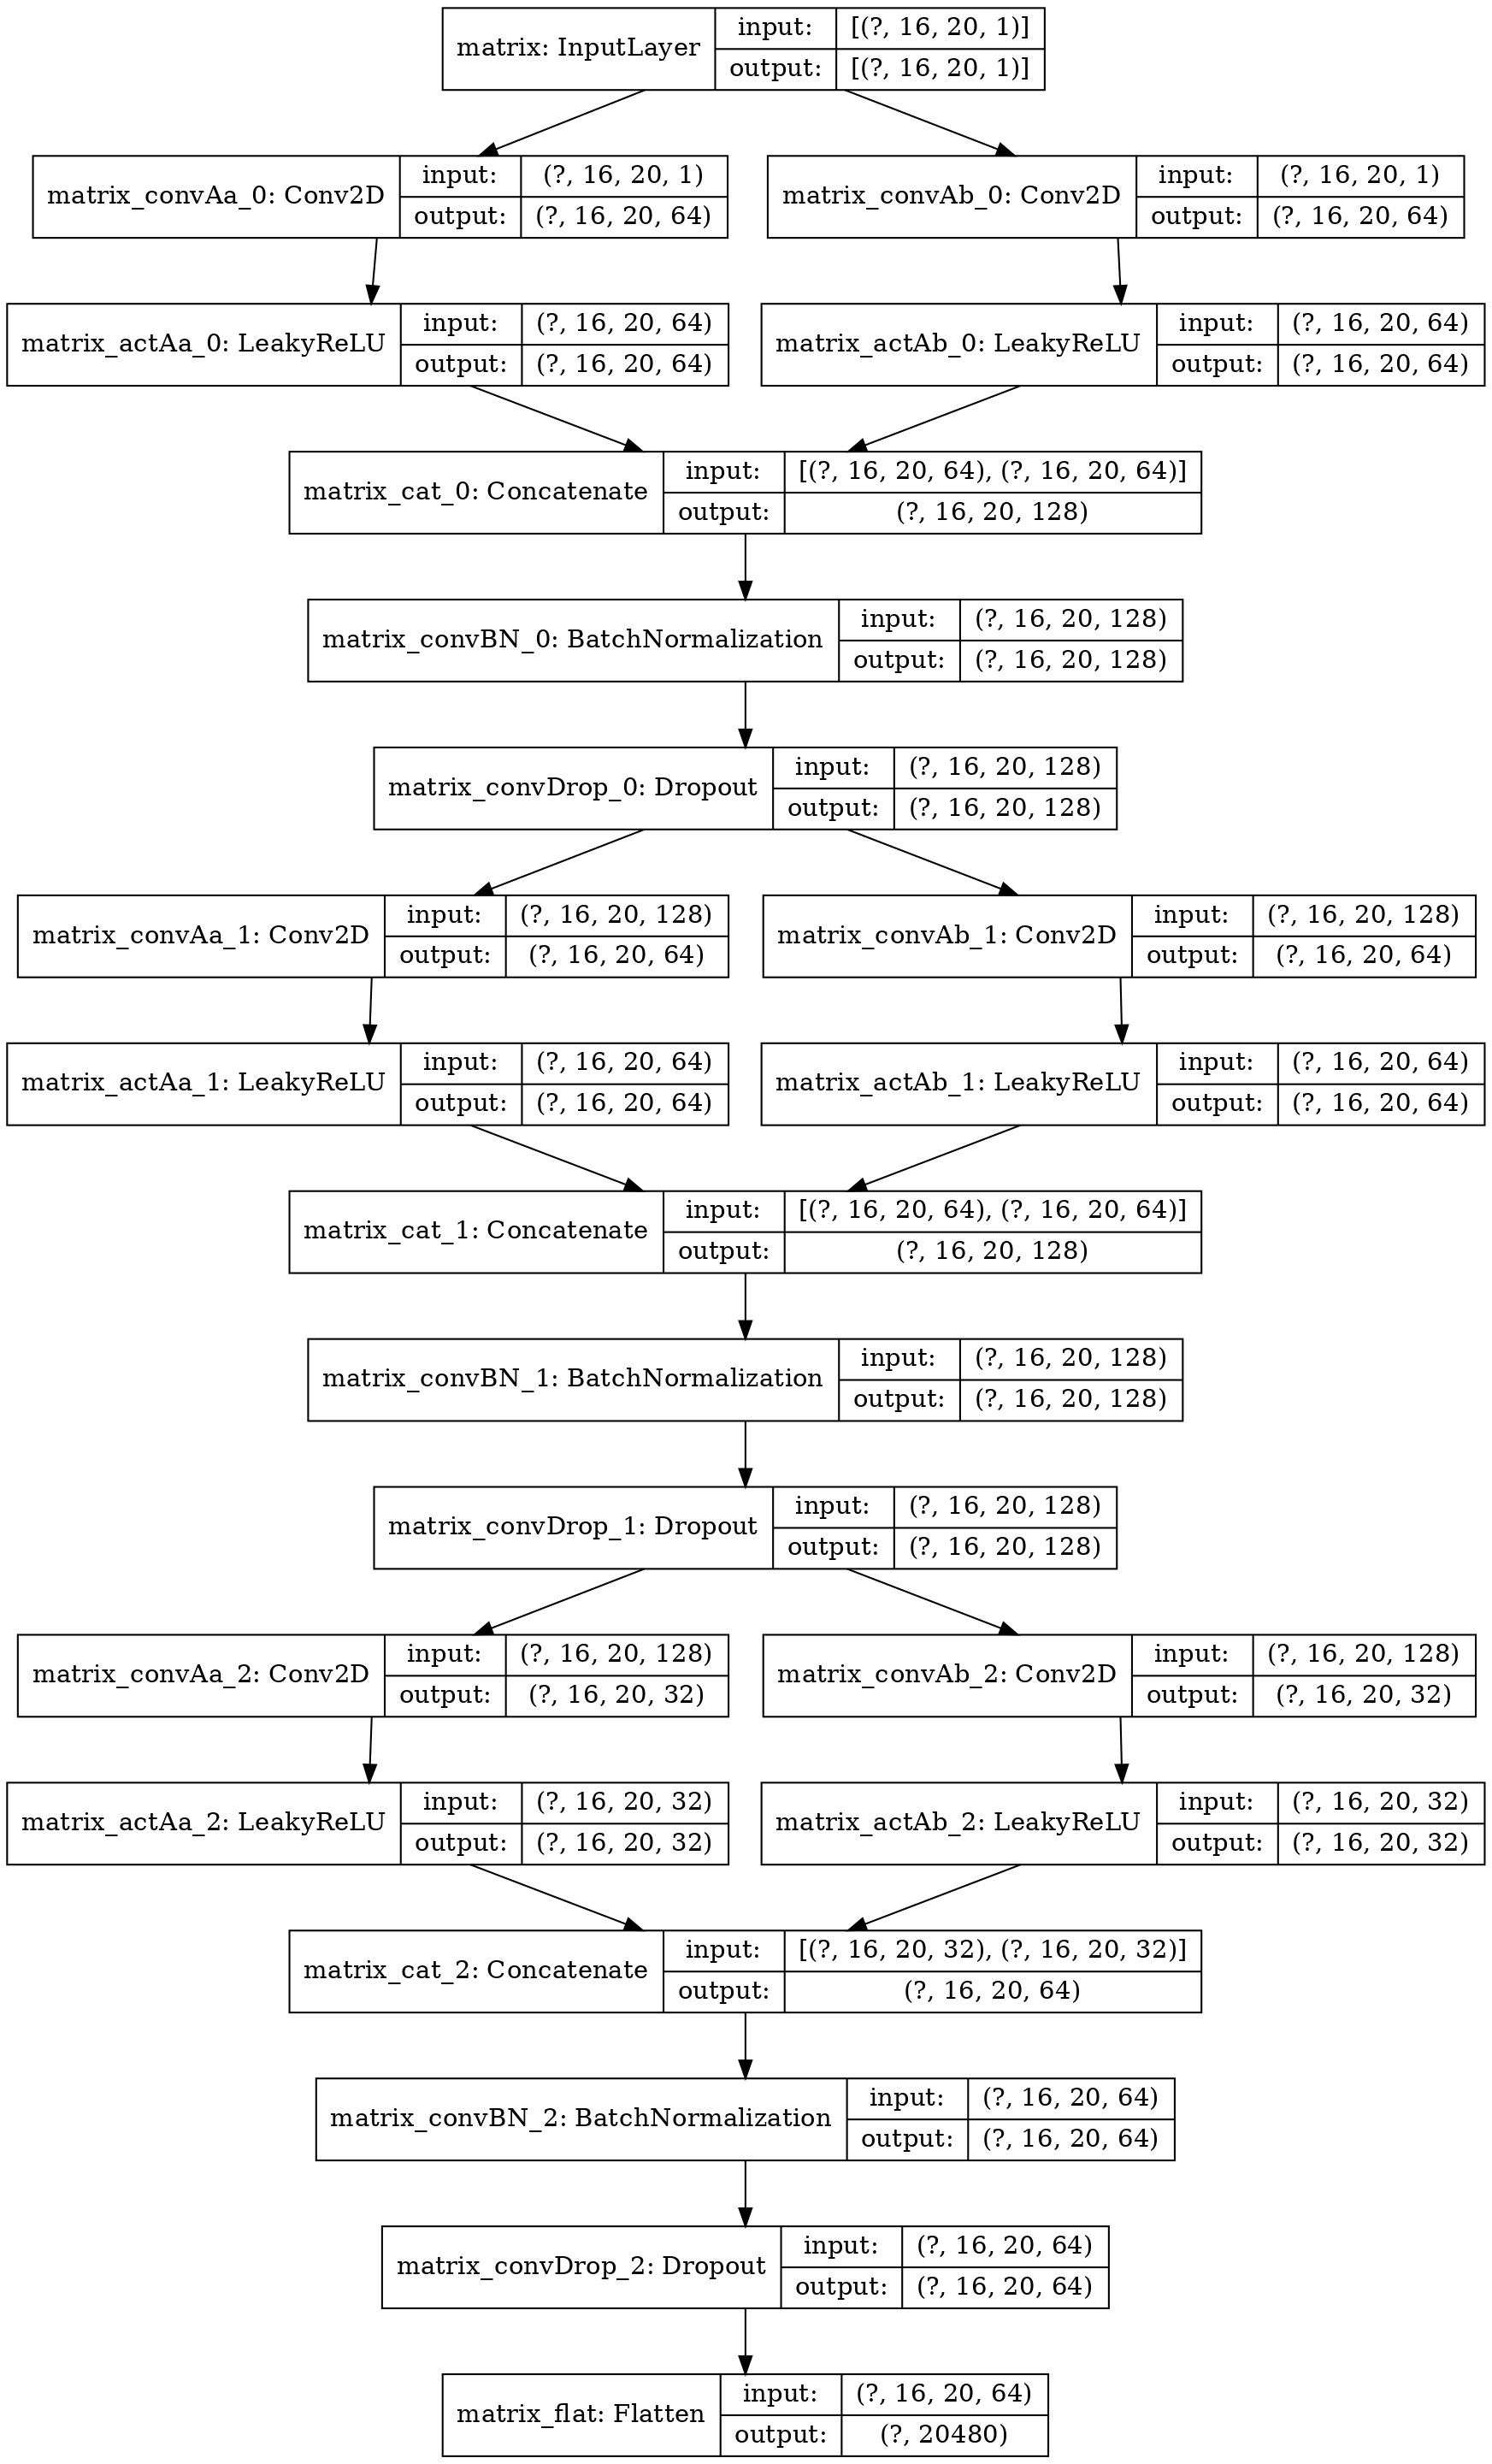

In [27]:
matrix_graph = keras.utils.model_to_dot(matrix, show_shapes=True, dpi=150)
matrix_graph.write_pdf(pimg(PREFIX + 'matrix_graph' + SUFFIX + '.pdf'))
Image(matrix_graph.create_png(), width=480)

### Dense Network

In [56]:
scalars = nn_dense(input_shape=scalars_shape,
                   name='scalars',
                   learning_rate=1.0e-3,
                   recurrent=False,
                   fc_layers=[10, 10, 5],
                   fc_alpha=0.0,
                   dropout=0.1,
                   batchnorm=0.99,
                   last_relu=True,
                   loss_weights=[0.25, 0.25, 0.25, 0.25],
                   l1_reg=1.0e-5,
                   l2_reg=1.0e-5,
                   output_layers=False
                  )

scalars.summary()

Model: "scalars"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
scalars (InputLayer)            [(None, 5)]          0                                            
__________________________________________________________________________________________________
scalars_fc_0 (Dense)            (None, 10)           60          scalars[0][0]                    
__________________________________________________________________________________________________
scalars_fcAct_0 (LeakyReLU)     (None, 10)           0           scalars_fc_0[0][0]               
__________________________________________________________________________________________________
scalars_fcBN_0 (BatchNormalizat (None, 10)           40          scalars_fcAct_0[0][0]            
____________________________________________________________________________________________

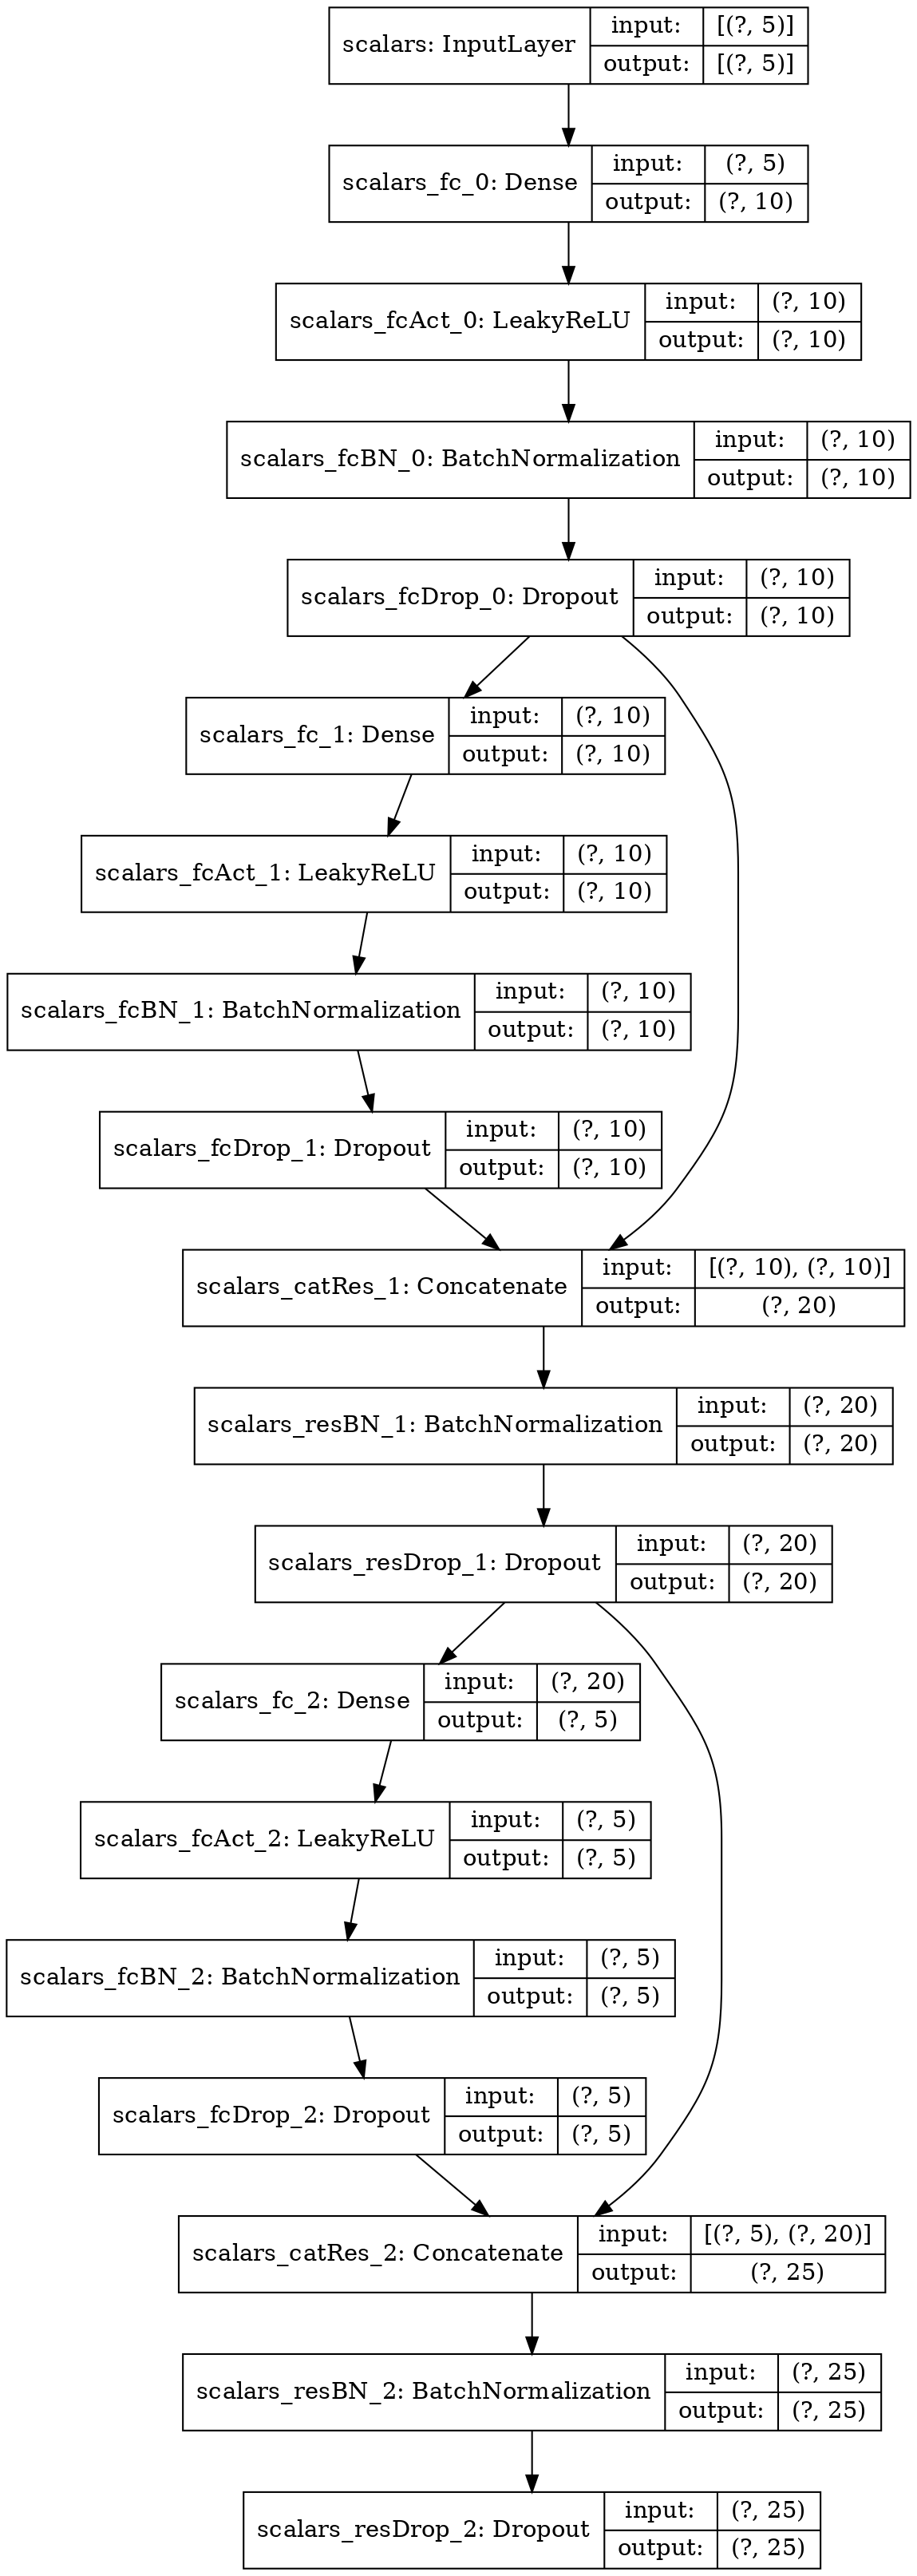

In [57]:
scalars_graph = keras.utils.model_to_dot(scalars, show_shapes=True, dpi=150)
scalars_graph.write_pdf(pimg(PREFIX + 'scalars_graph' + SUFFIX + '.pdf'))
Image(scalars_graph.create_png(), width=480)

In [30]:
dim_cp = nn_dense(input_shape=dim_cp_shape,
                  name='dim_cp',
                  learning_rate=1.0e-3,
                  recurrent=False,
                  fc_layers=[20, 10, 5],
                  fc_alpha=0.0,
                  dropout=0.1,
                  batchnorm=0.99,
                  last_relu=True,
                  loss_weights=[0.25, 0.25, 0.25, 0.25],
                  l1_reg=1.0e-5,
                  l2_reg=1.0e-5,
                  output_layers=False
                 )

dim_cp.summary()

Model: "dim_cp"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dim_cp (InputLayer)          [(None, 16)]              0         
_________________________________________________________________
dim_cp_fc_0 (Dense)          (None, 20)                340       
_________________________________________________________________
dim_cp_fcAct_0 (LeakyReLU)   (None, 20)                0         
_________________________________________________________________
dim_cp_fcBN_0 (BatchNormaliz (None, 20)                80        
_________________________________________________________________
dim_cp_fcDrop_0 (Dropout)    (None, 20)                0         
_________________________________________________________________
dim_cp_fc_1 (Dense)          (None, 10)                210       
_________________________________________________________________
dim_cp_fcAct_1 (LeakyReLU)   (None, 10)                0    

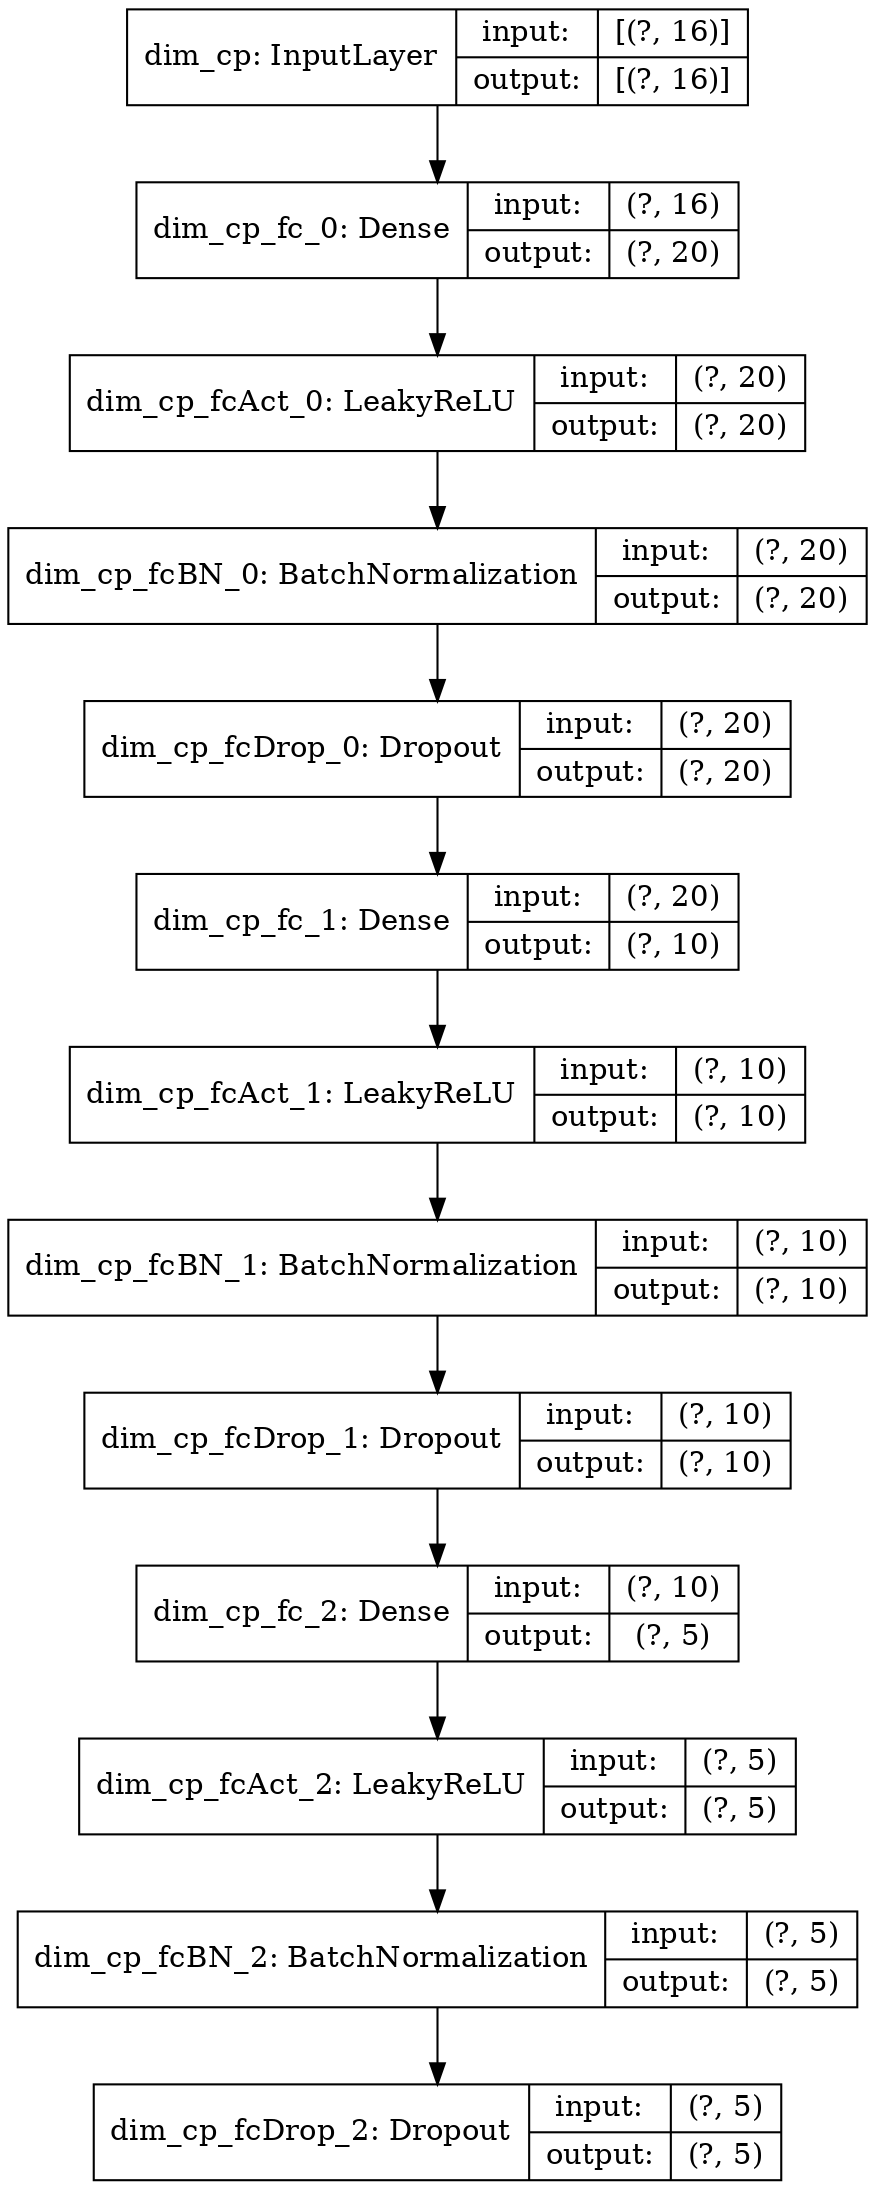

In [31]:
dim_cp_graph = keras.utils.model_to_dot(dim_cp, show_shapes=True, dpi=150)
dim_cp_graph.write_pdf(pimg(PREFIX + 'dim_cp_graph' + SUFFIX + '.pdf'))
Image(dim_cp_graph.create_png(), width=480)

In [32]:
deg_eqs = nn_dense(input_shape=deg_eqs_shape,
                   name='deg_eqs',
                   learning_rate=1.0e-3,
                   recurrent=False,
                   fc_layers=[20, 10, 5],
                   fc_alpha=0.0,
                   dropout=0.1,
                   batchnorm=0.99,
                   last_relu=True,
                   loss_weights=[0.25, 0.25, 0.25, 0.25],
                   l1_reg=1.0e-5,
                   l2_reg=1.0e-5,
                   output_layers=False
                  )

deg_eqs.summary()

Model: "deg_eqs"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
deg_eqs (InputLayer)         [(None, 16)]              0         
_________________________________________________________________
deg_eqs_fc_0 (Dense)         (None, 20)                340       
_________________________________________________________________
deg_eqs_fcAct_0 (LeakyReLU)  (None, 20)                0         
_________________________________________________________________
deg_eqs_fcBN_0 (BatchNormali (None, 20)                80        
_________________________________________________________________
deg_eqs_fcDrop_0 (Dropout)   (None, 20)                0         
_________________________________________________________________
deg_eqs_fc_1 (Dense)         (None, 10)                210       
_________________________________________________________________
deg_eqs_fcAct_1 (LeakyReLU)  (None, 10)                0   

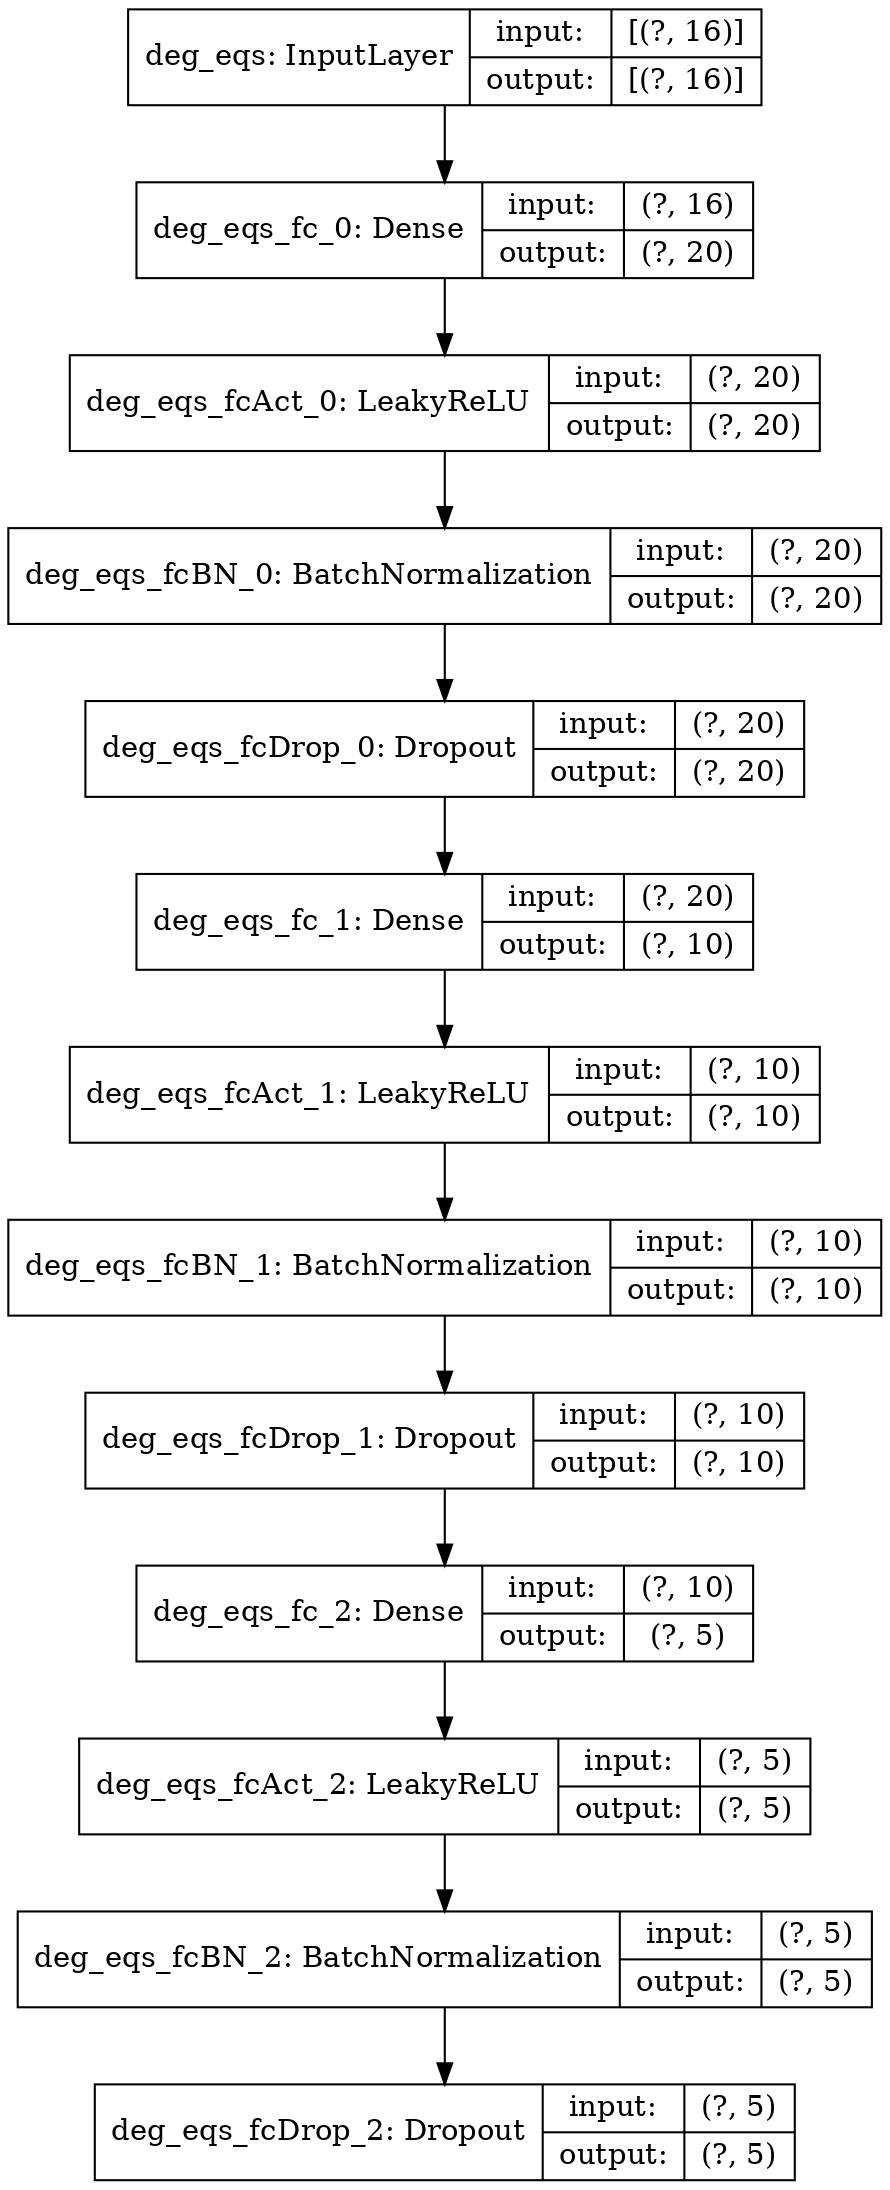

In [33]:
deg_eqs_graph = keras.utils.model_to_dot(deg_eqs, show_shapes=True, dpi=150)
deg_eqs_graph.write_pdf(pimg(PREFIX + 'deg_eqs_graph' + SUFFIX + '.pdf'))
Image(deg_eqs_graph.create_png(), width=480)

### Full Model

In [34]:
full_model = nn_full([matrix, scalars, dim_cp, deg_eqs],
                     name='full_model',
                     learning_rate=1.0e-3,
                     last_relu=True,
                     fc_layers=[20],
                     fc_alpha=0.0,
                     batchnorm=0.99,
                     dropout=0.0,
                     loss_weights=[0.25, 0.25, 0.25, 0.25],
                     l1_reg=0.0,
                     l2_reg=0.0
                    )
full_model.summary()

Model: "full_model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
matrix (InputLayer)             [(None, 16, 20, 1)]  0                                            
__________________________________________________________________________________________________
matrix_convAa_0 (Conv2D)        (None, 16, 20, 64)   1088        matrix[0][0]                     
__________________________________________________________________________________________________
matrix_convAb_0 (Conv2D)        (None, 16, 20, 64)   1344        matrix[0][0]                     
__________________________________________________________________________________________________
matrix_actAa_0 (LeakyReLU)      (None, 16, 20, 64)   0           matrix_convAa_0[0][0]            
_________________________________________________________________________________________

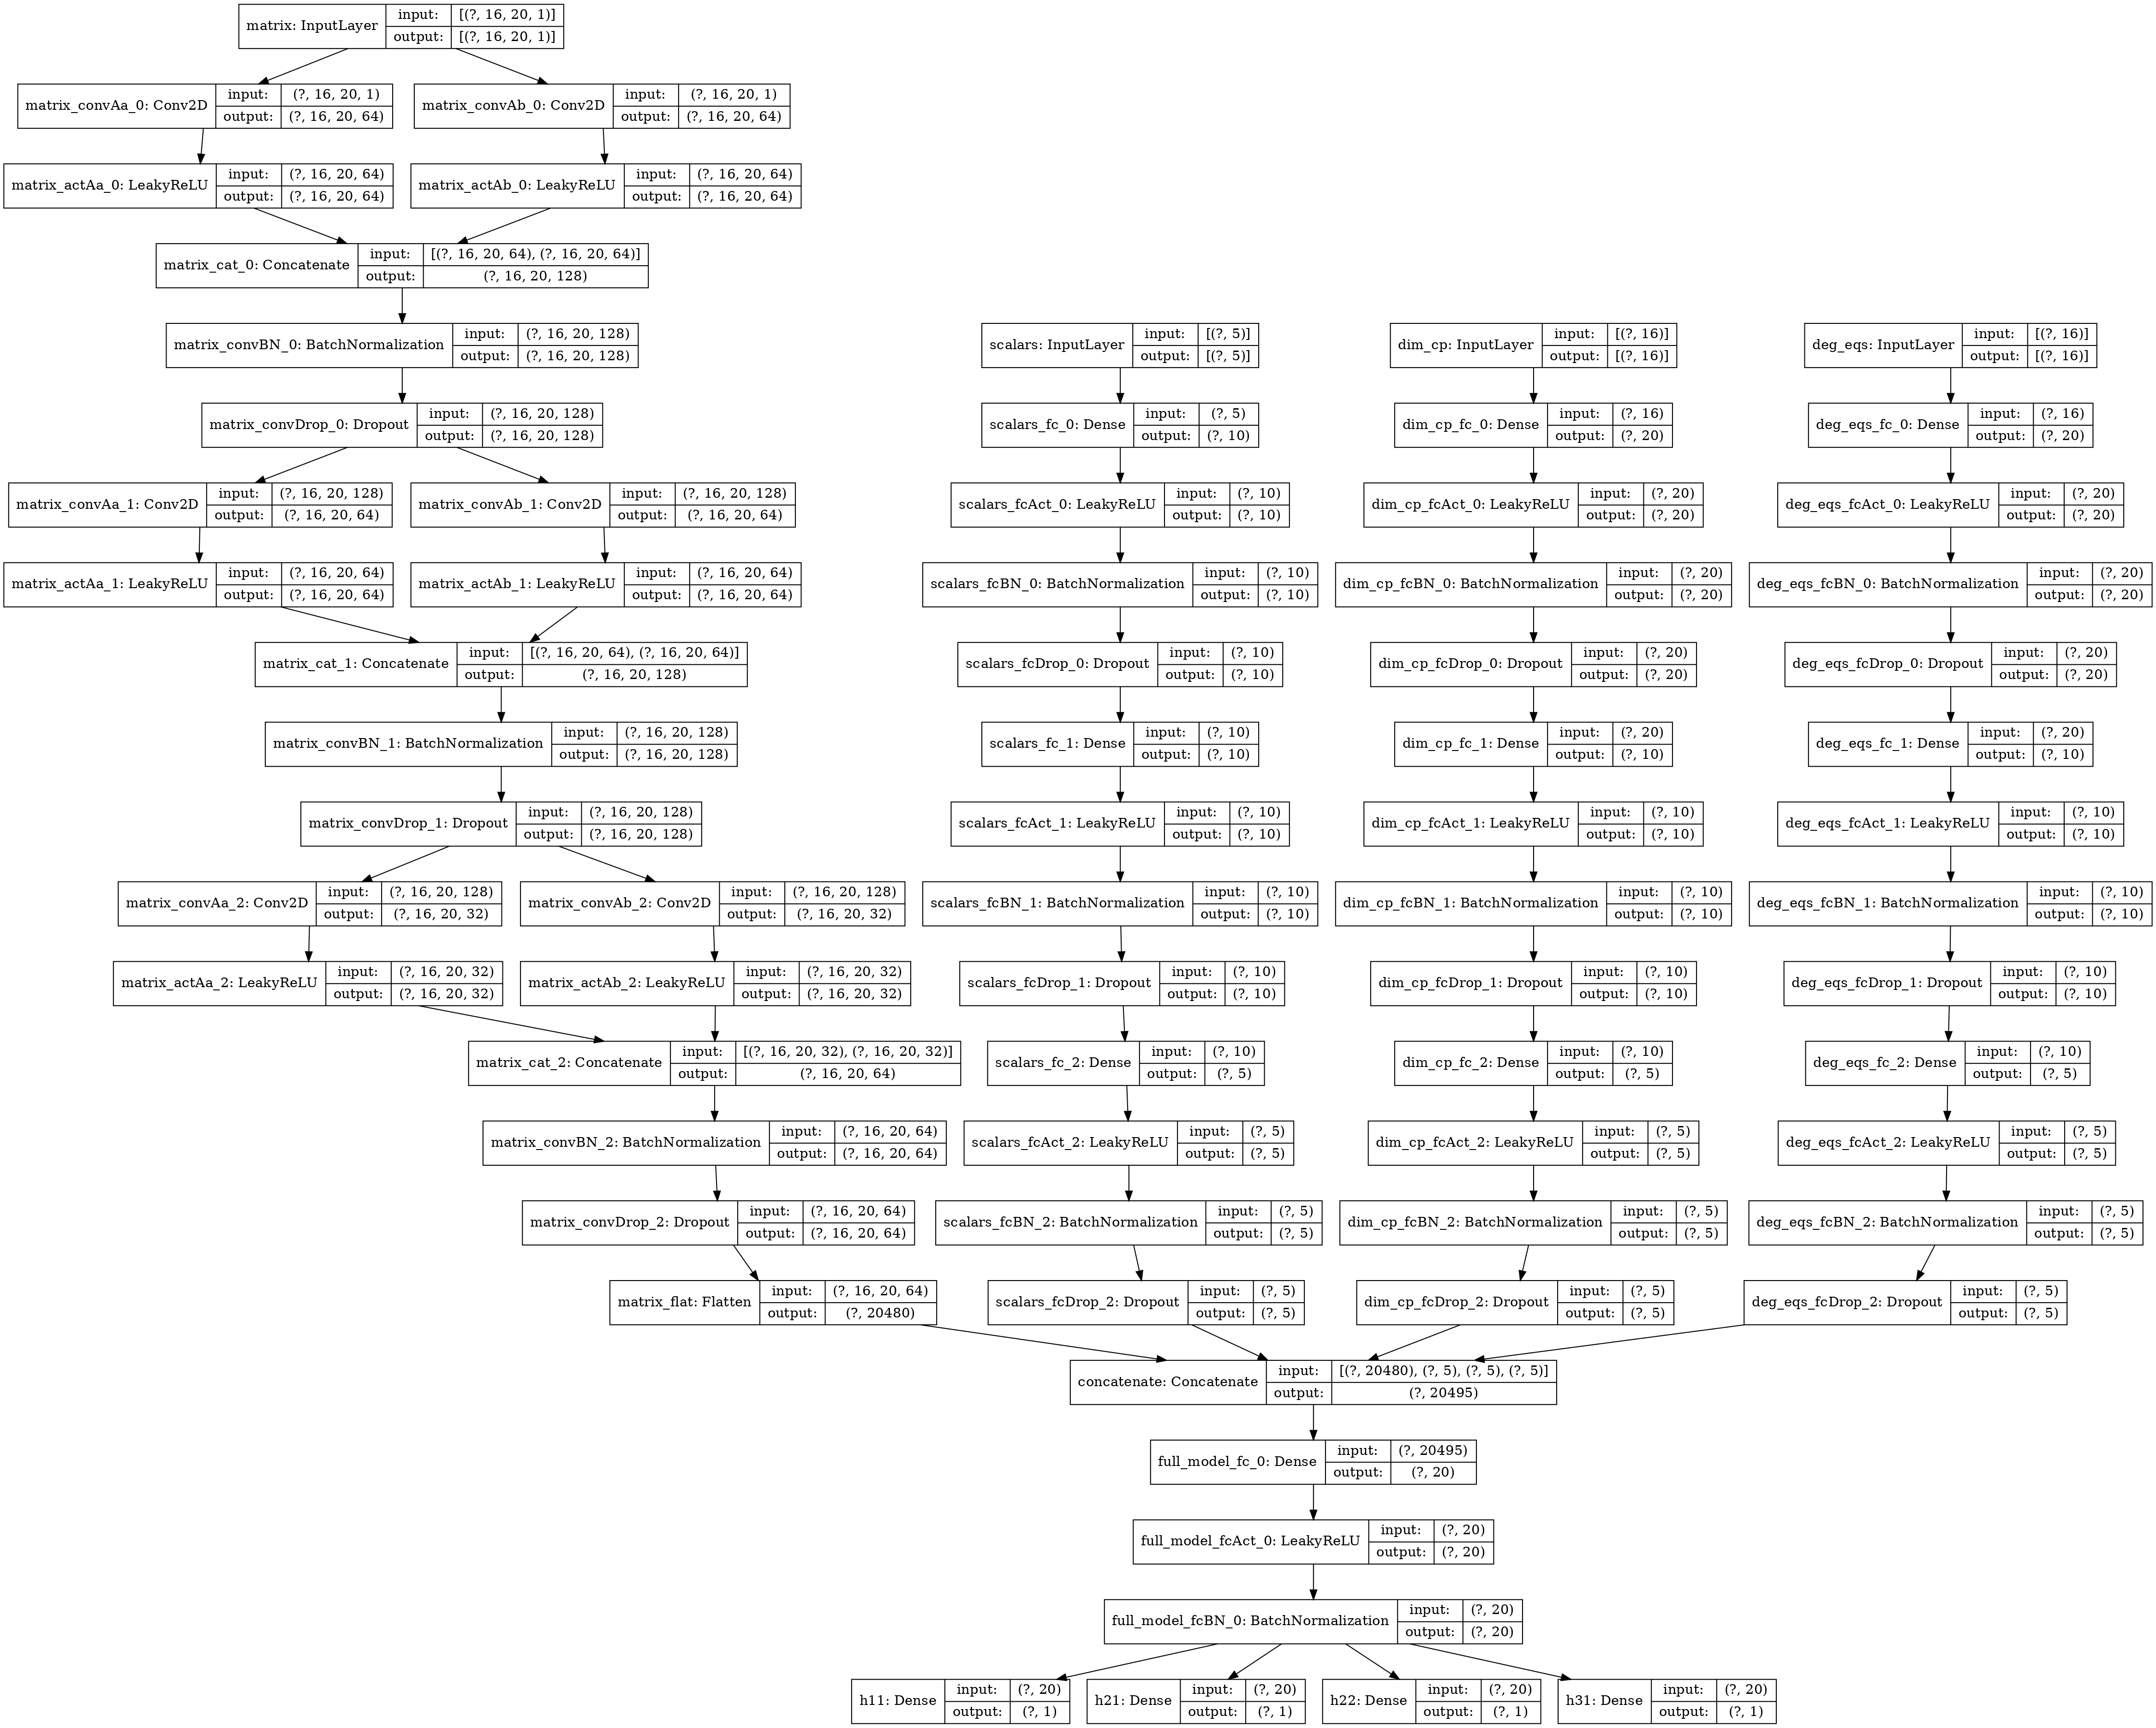

In [35]:
full_model_graph = keras.utils.model_to_dot(full_model, show_shapes=True, dpi=150)
full_model_graph.write_pdf(pimg(PREFIX + 'full_model_graph' + SUFFIX + '.pdf'))
Image(full_model_graph.create_png(), width=480)

## Training the Model

In [36]:
epochs = 160

In [37]:
full_model_hst = full_model.fit(train,
                                batch_size=batch_size,
                                epochs=epochs,
                                verbose=0,
                                callbacks=[keras.callbacks.ModelCheckpoint(pdata(PREFIX + 'inception' + SUFFIX + '.h5'), save_best_only=True),
                                           #keras.callbacks.EarlyStopping(patience=50, restore_best_weights=True),
                                           keras.callbacks.ReduceLROnPlateau(factor=0.3, patience=25, min_lr=1.0e-6)
                                          ],
                                validation_data=val
                               )

In [38]:
full_model = keras.models.load_model(pdata(PREFIX + 'inception' + SUFFIX + '.h5'))

In [39]:
history = pd.DataFrame(full_model_hst.history)

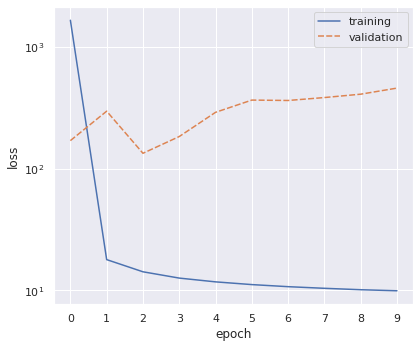

In [40]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.lineplot(data=history[['loss', 'val_loss']],
             ax=ax
            )
ax.set_xlabel('epoch')
ax.set_ylabel('loss')
ax.set_yscale('log')

step = int(epochs / 10) if epochs > 10 else 1
ax.set_xticks(np.arange(0, epochs, step))
ax.legend(['training', 'validation'], loc='best')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'loss_functions' + SUFFIX + '.pdf'), format='pdf', dpi=150)

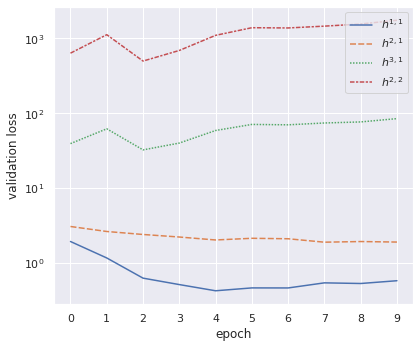

In [41]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.lineplot(data=history[['val_h11_loss', 'val_h21_loss', 'val_h31_loss', 'val_h22_loss']],
             ax=ax
            )
ax.set_xlabel('epoch')
ax.set_ylabel('validation loss')
ax.set_yscale('log')

step = int(epochs / 10) if epochs > 10 else 1
ax.set_xticks(np.arange(0, epochs, step))
ax.legend(['$h^{1,1}$', '$h^{2,1}$', '$h^{3,1}$', '$h^{2,2}$'], loc='best')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'val_loss_functions' + SUFFIX + '.pdf'), format='pdf', dpi=150)

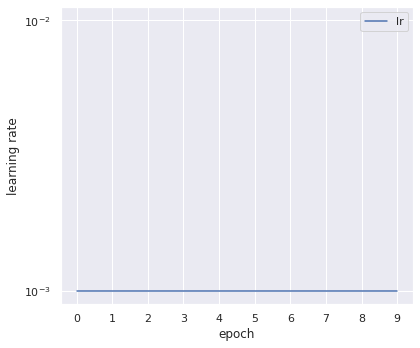

In [42]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.lineplot(data=history[['lr']],
             ax=ax
            )
ax.set_xlabel('epoch')
ax.set_ylabel('learning rate')
ax.set_yscale('log')

step = int(epochs / 10) if epochs > 10 else 1
ax.set_xticks(np.arange(0, epochs, step))

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'learning_rate' + SUFFIX + '.pdf'), format='pdf', dpi=150)

## Computing Metrics and Predictions

In [43]:
_ = full_model.evaluate(test, verbose=1)

142/142 [==============================] - 1s 7ms/step - loss: 152.1304 - h11_loss: 0.6547 - h21_loss: 2.4798 - h22_loss: 566.4083 - h31_loss: 36.8806 - h11_mean_squared_error: 0.6547 - h11_mean_absolute_error: 0.5401 - h21_mean_squared_error: 2.4798 - h21_mean_absolute_error: 0.6985 - h22_mean_squared_error: 566.4083 - h22_mean_absolute_error: 6.9979 - h31_mean_squared_error: 36.8806 - h31_mean_absolute_error: 1.8765


In [44]:
train_predictions = full_model.predict(train)
train_predictions = {key: list(np.rint(value.reshape(-1,)).astype(np.float64)) for key, value in train_predictions.items()}
val_predictions   = full_model.predict(val)
val_predictions   = {key: list(np.rint(value.reshape(-1,)).astype(np.float64)) for key, value in val_predictions.items()}
test_predictions  = full_model.predict(test)
test_predictions  = {key: list(np.rint(value.reshape(-1,)).astype(np.float64)) for key, value in test_predictions.items()}

# save predictions to file
with open(pdata(PREFIX + 'train_predictions' + SUFFIX + '.json'), 'w') as f:
    json.dump(train_predictions, f)
with open(pdata(PREFIX + 'val_predictions' + SUFFIX + '.json'), 'w') as f:
    json.dump(val_predictions, f)
with open(pdata(PREFIX + 'test_predictions' + SUFFIX + '.json'), 'w') as f:
    json.dump(test_predictions, f)

In [45]:
# compute metrics
metrics = {}
hodges  = ['h11', 'h21', 'h31', 'h22']
metrics['train_mse'] = [mean_squared_error(train_labels[c], train_predictions[c]) for c in hodges]
metrics['val_mse']   = [mean_squared_error(val_labels[c], val_predictions[c]) for c in hodges]
metrics['test_mse']  = [mean_squared_error(test_labels[c], test_predictions[c]) for c in hodges]
metrics['train_mae'] = [mean_absolute_error(train_labels[c], train_predictions[c]) for c in hodges]
metrics['val_mae']   = [mean_absolute_error(val_labels[c], val_predictions[c]) for c in hodges]
metrics['test_mae']  = [mean_absolute_error(test_labels[c], test_predictions[c]) for c in hodges]
metrics['train_r2']  = [r2_score(train_labels[c], train_predictions[c]) for c in hodges]
metrics['val_r2']    = [r2_score(val_labels[c], val_predictions[c]) for c in hodges]
metrics['test_r2']   = [r2_score(test_labels[c], test_predictions[c]) for c in hodges]
metrics['train_acc'] = [accuracy_score(train_labels[c], np.rint(train_predictions[c]).astype(np.int)) for c in hodges]
metrics['val_acc']   = [accuracy_score(val_labels[c], np.rint(val_predictions[c]).astype(np.int)) for c in hodges]
metrics['test_acc']  = [accuracy_score(test_labels[c], np.rint(test_predictions[c]).astype(np.int)) for c in hodges]

metrics = pd.DataFrame(metrics, index=hodges)
metrics.to_csv(pdata(PREFIX + 'metrics' + SUFFIX + '.csv'))
metrics

,train_mse,val_mse,test_mse,train_mae,val_mae,test_mae,train_r2,val_r2,test_r2,train_acc,val_acc,test_acc
h11,0.411786,0.698244,0.727504,0.366780,0.445181,0.463178,0.888115,0.877835,0.878783,0.653124,0.631335,0.617754
h21,0.777546,2.435906,2.532848,0.456443,0.666667,0.669537,0.339079,0.301069,0.283824,0.657146,0.633985,0.636745
h31,1.742437,32.336646,36.901071,0.898775,1.772441,1.840234,0.973713,0.819874,0.805627,0.384971,0.342277,0.342718
h22,21.765931,497.502153,566.685547,3.337184,6.780280,6.993817,0.972891,0.787746,0.771180,0.110466,0.102462,0.106768


In [46]:
train_residuals = {key: np.subtract(train_labels[key], train_predictions[key]) for key in train_labels.keys()}
val_residuals   = {key: np.subtract(val_labels[key], val_predictions[key]) for key in val_labels.keys()}
test_residuals  = {key: np.subtract(test_labels[key], test_predictions[key]) for key in test_labels.keys()}

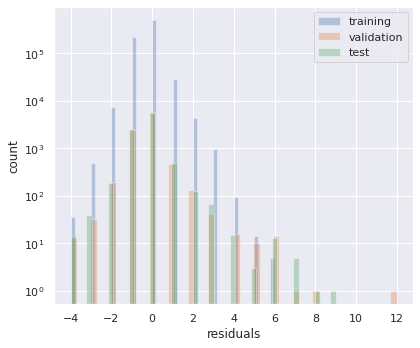

In [47]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.distplot(train_residuals['h11'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
sns.distplot(val_residuals['h11'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
sns.distplot(test_residuals['h11'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'])

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h11_residuals_hist' + SUFFIX + '.pdf'), format='pdf', dpi=150)

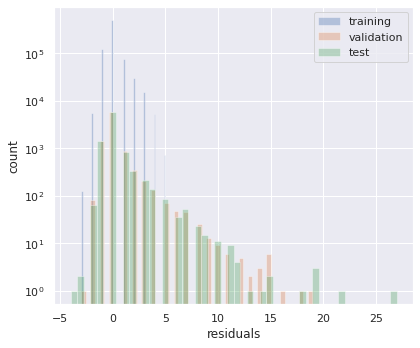

In [48]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.distplot(train_residuals['h21'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
sns.distplot(val_residuals['h21'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
sns.distplot(test_residuals['h21'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'])

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h21_residuals_hist' + SUFFIX + '.pdf'), format='pdf', dpi=150)

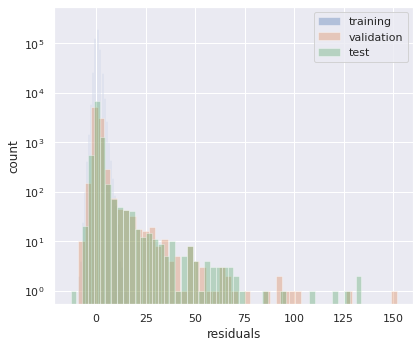

In [49]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.distplot(train_residuals['h31'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
sns.distplot(val_residuals['h31'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
sns.distplot(test_residuals['h31'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'])

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h31_residuals_hist' + SUFFIX + '.pdf'), format='pdf', dpi=150)

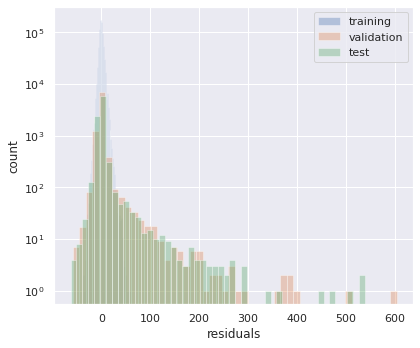

In [50]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.distplot(train_residuals['h22'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
sns.distplot(val_residuals['h22'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
sns.distplot(test_residuals['h22'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'])

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h22_residuals_hist' + SUFFIX + '.pdf'), format='pdf', dpi=150)

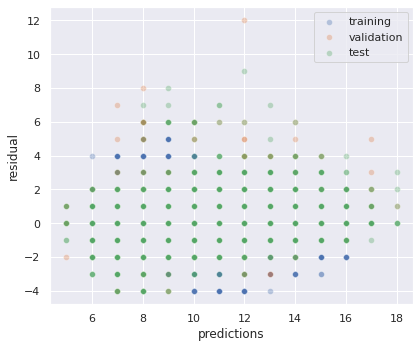

In [51]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h11'],
                y=train_residuals['h11'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h11'],
                y=val_residuals['h11'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h11'],
                y=test_residuals['h11'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residual')
ax.legend(['training', 'validation', 'test'])

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h11_residuals' + SUFFIX + '.pdf'), format='pdf', dpi=150)

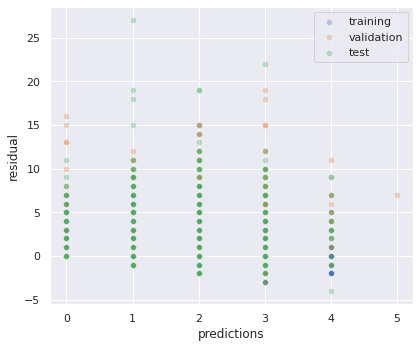

In [52]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h21'],
                y=train_residuals['h21'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h21'],
                y=val_residuals['h21'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h21'],
                y=test_residuals['h21'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residual')
ax.legend(['training', 'validation', 'test'])

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h21_residuals' + SUFFIX + '.pdf'), format='pdf', dpi=150)

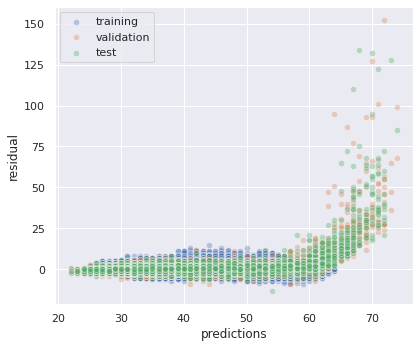

In [53]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h31'],
                y=train_residuals['h31'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h31'],
                y=val_residuals['h31'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h31'],
                y=test_residuals['h31'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residual')
ax.legend(['training', 'validation', 'test'])

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h31_residuals' + SUFFIX + '.pdf'), format='pdf', dpi=150)

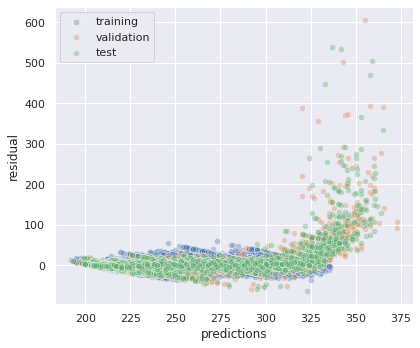

In [54]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h22'],
                y=train_residuals['h22'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h22'],
                y=val_residuals['h22'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h22'],
                y=test_residuals['h22'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residual')
ax.legend(['training', 'validation', 'test'])

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h22_residuals' + SUFFIX + '.pdf'), format='pdf', dpi=150)